In [87]:
"""Amazon Product Review Sentiment and Authenticity Detection"""

'Amazon Product Review Sentiment and Authenticity Detection'

In [88]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [89]:
import kagglehub

path = kagglehub.dataset_download("mexwell/fake-reviews-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-reviews-dataset' dataset.
Path to dataset files: /kaggle/input/fake-reviews-dataset


In [90]:
import os

file_list = os.listdir(path)
print("Files in the dataset directory:")
for f in file_list:
    print(f)

Files in the dataset directory:
fake reviews dataset.csv


In [91]:

file_list = os.listdir(path)
print("Files in the dataset directory:")
for f in file_list:
    print(f)

csv_file = os.path.join(path, "fake reviews dataset.csv")

df = pd.read_csv(csv_file)

print(df.shape)
print(df.head())



Files in the dataset directory:
fake reviews dataset.csv
(40432, 4)
             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information on how to use it, but it i...  
4  Very nice set. Good quality. We have had the s...  


# Visualizing the Dataset Before the Model

In [92]:
#insert scatter/correlatoin plots here

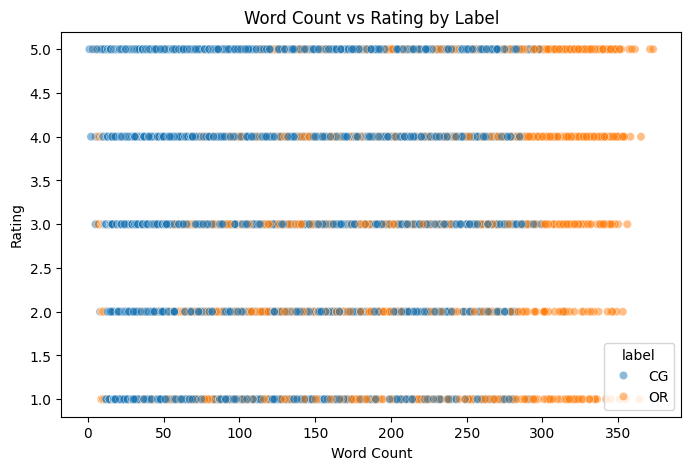

In [96]:
df["word_count"] = df["text_"].str.split().apply(len)

plt.figure(figsize=(8,5))
sns.scatterplot(x="word_count", y="rating", hue="label", data=df, alpha=0.5)
plt.title("Word Count vs Rating by Label")
plt.xlabel("Word Count")
plt.ylabel("Rating")
plt.show()


In [99]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_text = " ".join(df[df["target"] == 0]["text_"].astype(str))

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    min_font_size=10
)

fake_wc = wc.generate(fake_text)

plt.figure(figsize=(14,7))
plt.imshow(fake_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Wordcloud of Fake Reviews (target = 0)", fontsize=16)
plt.show()


KeyError: 'target'

In [98]:
real_text = " ".join(df[df["target"] == 1]["text_"].astype(str))

real_wc = wc.generate(real_text)

plt.figure(figsize=(14,7))
plt.imshow(real_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Wordcloud of Real Reviews (target = 1)", fontsize=16)
plt.show()


KeyError: 'target'

#Feature Engineering

Next, now that we have sampled a portion of the dataset (50,000 reviews), we want to add addiotional features because we are only given 2 -- the review rating split into a binary classification and the review text. We thought about what features could differentiate reviews into fake vs genuine, and came up with the following.

## 1. Word Count
### Reasoning:
Fake reviews tend to be either really short or really long.
## 2. Number of Exclamation & Questions Marks
### Reasoning:
Fake reviews are exaggerated, and so tend to have more extreme punctuation.
## 3. Sentiment Score: VADER
### Reasoning:
Fake reviews tend to be either highly negative or positive.

In [100]:
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def add_review_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["word_count"] = df["text_"].str.split().str.len()

    df["exclamation_count"] = df["text_"].str.count("!")
    df["question_count"]   = df["text_"].str.count(r"\?")
    df["punctuation_emphasis"] = df["exclamation_count"] + df["question_count"]

    df["vader_compound"] = df["text_"].apply(
        lambda t: sia.polarity_scores(str(t))["compound"]
    )

    return df

train_df_featurized = add_review_features(df)

print(train_df_featurized.head())


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  word_count  \
0  Love this!  Well made, sturdy, and very comfor...          12   
1  love it, a great upgrade from the original.  I...          16   
2  This pillow saved my back. I love the look and...          14   
3  Missing information on how to use it, but it i...          17   
4  Very nice set. Good quality. We have had the s...          18   

   exclamation_count  question_count  punctuation_emphasis  vader_compound  
0                  2               0                     2          0.9593  
1                  0               0                     0          0.8910  
2                  0               0                     0          0.7906  
3                  1               0            

# Defining Columns and Preprocessing Transformer

In [101]:
df = train_df_featurized

text_col = "text_"

numeric_cols = [
    "word_count",
    "punctuation_emphasis",
    "vader_compound",
    "rating"
]

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    stop_words='english'
)

preprocess = ColumnTransformer(
    transformers=[
        ("tfidf", tfidf, text_col),
        ("num", StandardScaler(), numeric_cols)
    ],
    remainder="drop"
)



# Model 1: Linear SVM
## Pipeline

In [102]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LinearSVC())
])

# Train-Test Split + Fitting Model

In [103]:
from sklearn.model_selection import train_test_split

X = df["text_"]
y = df["label"]

X_full = df

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=30000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'text_'),
                                                 ('num', StandardScaler(),
                                                  ['word_count',
                                                   'punctuation_emphasis',
                                                   'vader_compound',
                                                   'rating'])])),
                ('clf', LinearSVC())])

# Evaluate

In [104]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9037962161493756
              precision    recall  f1-score   support

          CG       0.91      0.89      0.90      4044
          OR       0.89      0.92      0.90      4043

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087



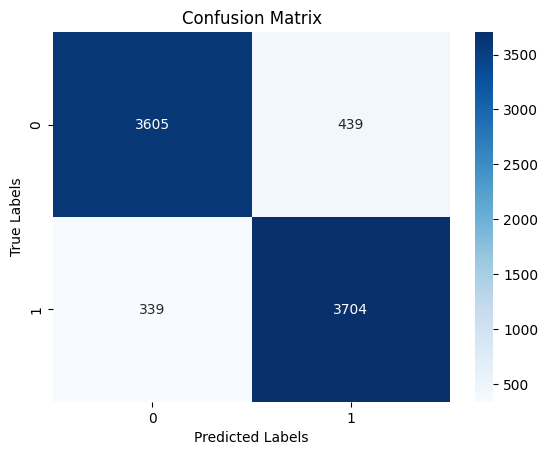

In [105]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Model 2: Logistic Regression

In [110]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report



text_col = "text_"
numeric_cols = ["word_count", "punctuation_emphasis", "vader_compound", "rating"]

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    stop_words="english"
)

preprocess = ColumnTransformer(
    transformers=[
        ("tfidf", tfidf, text_col),
        ("num", StandardScaler(), numeric_cols)
    ],
    remainder="drop"
)


log_reg_clf = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced"
    ))
])


X = df[[text_col] + numeric_cols]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_reg_clf.fit(X_train, y_train)

y_pred = log_reg_clf.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.8668232966489428

Classification Report:
               precision    recall  f1-score   support

          CG       0.88      0.85      0.86      4044
          OR       0.86      0.88      0.87      4043

    accuracy                           0.87      8087
   macro avg       0.87      0.87      0.87      8087
weighted avg       0.87      0.87      0.87      8087



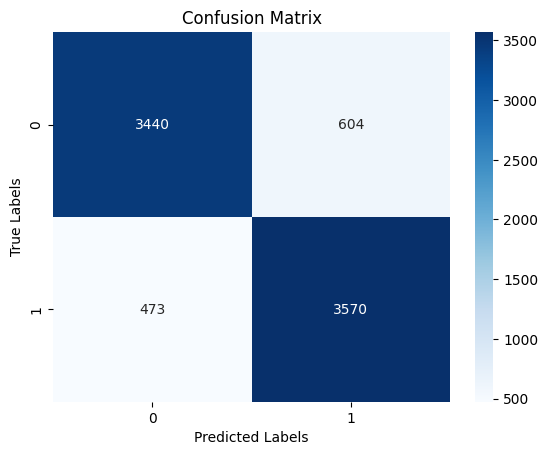

In [112]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
#

# Model 3: Random Forest

In [108]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

text_col = "text_"
numeric_cols = ["word_count", "punctuation_emphasis", "vader_compound", "rating"]

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english"
)

preprocess = ColumnTransformer(
    transformers=[
        ("tfidf", tfidf, text_col),
        ("num", StandardScaler(), numeric_cols)
    ],
    remainder="drop"
)

rf_clf = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

X = df[[text_col] + numeric_cols]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Random Forest Accuracy: 0.8704092988747373

Classification Report:
               precision    recall  f1-score   support

          CG       0.89      0.85      0.87      4044
          OR       0.86      0.89      0.87      4043

    accuracy                           0.87      8087
   macro avg       0.87      0.87      0.87      8087
weighted avg       0.87      0.87      0.87      8087



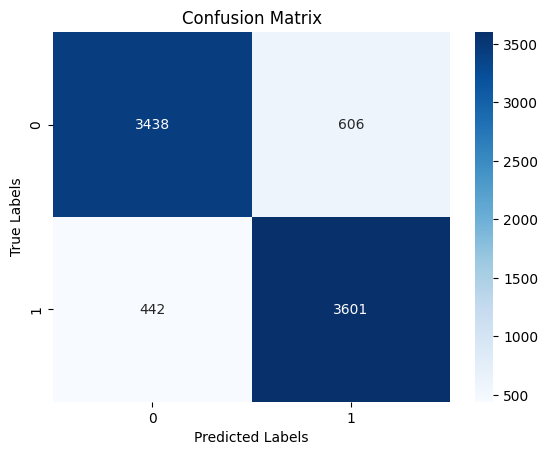

In [109]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Summary

LinearSVC performed the best out of the three models, as expected. Logistic regression performed the second best, while random forest performed the worst.